In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
import os
os.environ['SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL'] = 'True'

# Install dl4ds after TensorFlow to ensure compatibility
!pip install dl4ds climetlab

# Uninstall standalone Keras 3 (it removes LocallyConnected2D)
!pip uninstall keras -y

# Install TensorFlow 2.15 with CUDA support (last version with Keras 2 bundled)
!pip install "tensorflow[and-cuda]==2.15.*"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 MB 30.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 35.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 35.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 28.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 34.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 37.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 39.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.7/661.7 kB 48.0 MB/s  0:00:00
 

In [3]:
# ==========================================
# 🗂  Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                    — all hyper-parameters
#   runtime.log                    — epoch logs + timing
#   chart_*_config.json            — per-chart render config
#   srunet_training_curves.png     — loss/RMSE charts
#   srunet_eval_<date>.png         — spatial eval chart
#   metrics.csv                    — final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

# ── Runtime log helper ──────────────────────────────────────────────────
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# ── Chart-save helper ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved → {path}')
    return path

Run folder (placeholder): runs/20260402_004130_lead1d
[2026-04-02 00:41:30] === Run started  (id=20260402_004130) ===
[2026-04-02 00:41:30] Run dir: runs/20260402_004130_lead1d


## Import Library

In [5]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [6]:
## Config
# Perfect Prognosis: X = low-res ERA5, Y = high-res ERA5
# No NWP model lead time — set lead_days = 0 to mark PP scenario
lead_days = 0
scale = 6
seed = 42
BATCH_SIZE = 32

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

# ── Refresh RUN_DIR now that lead_days is defined ──────────────────────
RUN_DIR = os.path.join('runs', f'{_run_id}')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# ── Persist config ──────────────────────────────────────────────────────
_config = {
    'scenario'         : 'scenario2-unet-mae-perfect-prognosis',
    'lead_days'        : lead_days,
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved → {_cfg_path}')

Run folder: runs/20260402_004130
[2026-04-02 00:42:33] Config saved → runs/20260402_004130/config.json


In [7]:
# Reproducibility
np.random.seed(seed)

## Load Datasets

In [8]:
ds_hr = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [9]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_hr = ds_hr.sortby("latitude")  # ensure south → north

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
    ignore_degenerate=True,
)
ds_lr = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_lr.longitude)
LOW_LAT = len(ds_lr.latitude)

print(f"\nLow Resolution domain : lon {ds_lr.longitude.values[0]:.2f}→{ds_lr.longitude.values[-1]:.2f}"
      f"  lat {ds_lr.latitude.values[0]:.2f}→{ds_lr.latitude.values[-1]:.2f}")
print(f"high resolution domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal low resolution grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_lr.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_lr.latitude.values,  atol=1e-8)
assert lon_ok and lat_ok, "LR grid does not align with HR stride — check scale factor!"
print(f"Grid alignment check passed (lon_ok={lon_ok}, lat_ok={lat_ok})")

# ── Perfect Prognosis aliases ────────────────────────────────────────────
# Scenario 2 is Perfect Prognosis: the "forecast" input (X) is ERA5 itself
# degraded to low resolution.  There is no separate NWP model output.
#   ds_fc         → low-res ERA5  (predictor / pseudo-forecast, 24×32)
#   ds_tr_aligned → high-res ERA5 truth, cropped to the same domain (144×192)
ds_fc         = ds_lr   # alias — used throughout downstream cells
ds_tr_aligned = ds_tr   # alias — used throughout downstream cells
print("Perfect Prognosis aliases set:")
print(f"  ds_fc         = ds_lr  ({LOW_LAT}×{LOW_LON})")
print(f"  ds_tr_aligned = ds_tr  ({HIGH_LAT}×{HIGH_LON})")


lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Low Resolution domain : lon 90.00→136.50  lat -13.50→21.00
high resolution domain    : lon 90.00→137.75  lat -13.50→22.25

Final low resolution grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Grid alignment check passed (lon_ok=True, lat_ok=True)
Perfect Prognosis aliases set:
  ds_fc         = ds_lr  (24×32)
  ds_tr_aligned = ds_tr  (144×192)


## Check Missing Value

In [10]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_lr, "Low-res")
check_nan_summary(ds_hr, "Truth (High-res)")


==== Low-res ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## DL4DS Scenario 2 Runner (Perfect Prognosis)
This section trains DL4DS (ResNet + SPC) per variable using low-res ERA5 as input and high-res ERA5 as target.

In [11]:
import os
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import xarray as xr

import tensorflow as tf
import dl4ds as dds

if 'RUN_DIR' not in globals():
    RUN_DIR = os.path.join('runs', 'dl4ds_scenario2')
    os.makedirs(RUN_DIR, exist_ok=True)

scale = 6
lead_days = 0
lead_td = np.timedelta64(lead_days, 'D')

# Use Scenario-2 aliases if already prepared; otherwise fall back to ds_lr/ds_tr
fc_src = ds_fc if 'ds_fc' in globals() else ds_lr
tr_src = ds_tr_aligned if 'ds_tr_aligned' in globals() else ds_tr

fc_src = fc_src.sortby('latitude')
tr_src = tr_src.sortby('latitude')

# Lead-time handling for PP and forecast datasets
if 'prediction_timedelta' in fc_src.dims or 'prediction_timedelta' in fc_src.coords:
    fc_lead = fc_src.sel(prediction_timedelta=lead_td)
    valid_time = fc_lead.time + lead_td
    common_times = np.intersect1d(valid_time.values, tr_src.time.values)
    fc_lead = fc_lead.assign_coords(valid_time=valid_time).sel(valid_time=common_times)
    fc_lead = fc_lead.assign_coords(time=fc_lead.valid_time).drop_vars('valid_time')
    tr_aligned = tr_src.sel(time=common_times)
else:
    common_times = np.intersect1d(fc_src.time.values, tr_src.time.values)
    fc_lead = fc_src.sel(time=common_times)
    tr_aligned = tr_src.sel(time=common_times)

print(f"Common timesteps: {len(common_times)}")

# Variable list intersection to avoid missing-field crashes
default_vars = [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    'total_precipitation_24hr',
]
var_names = [v for v in default_vars if v in fc_lead.data_vars and v in tr_aligned.data_vars]
if not var_names:
    raise ValueError('No overlapping variables found between low-res input and high-res truth.')

print('Variables:', var_names)

# Date-based split masks (reuse existing notebook config if present)
all_times = tr_aligned.time.values
if all(k in globals() for k in ['train_start_date', 'train_end_date', 'val_start_date', 'val_end_date', 'test_start_date', 'test_end_date']):
    train_mask = (all_times >= np.datetime64(train_start_date)) & (all_times <= np.datetime64(train_end_date))
    val_mask = (all_times >= np.datetime64(val_start_date)) & (all_times <= np.datetime64(val_end_date))
    test_mask = (all_times >= np.datetime64(test_start_date)) & (all_times <= np.datetime64(test_end_date))
else:
    n_total = len(all_times)
    i1 = int(0.7 * n_total)
    i2 = int(0.85 * n_total)
    train_mask = np.zeros(n_total, dtype=bool); train_mask[:i1] = True
    val_mask = np.zeros(n_total, dtype=bool); val_mask[i1:i2] = True
    test_mask = np.zeros(n_total, dtype=bool); test_mask[i2:] = True

if not (train_mask.any() and val_mask.any() and test_mask.any()):
    raise ValueError('Invalid split: one of train/val/test is empty.')

ARCH_PARAMS = dict(
    n_filters=36,
    n_blocks=8,
    normalization=None,
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False,
)

trainers = {}
data = {}
norm_stats = {}

for i, var in enumerate(var_names, start=1):
    print(f"\n{'='*64}")
    print(f"Training DL4DS variable {i}/{len(var_names)}: {var}")
    print(f"{'='*64}")

    target_var = tr_aligned[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')
    input_var = fc_lead[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')

    train_idx = np.where(train_mask)[0]
    val_idx = np.where(val_mask)[0]
    test_idx = np.where(test_mask)[0]

    train_data = target_var.isel(time=train_idx).values
    mean_val = float(np.nanmean(train_data))
    std_val = float(np.nanstd(train_data))
    if std_val < 1e-8:
        std_val = 1.0

    norm_stats[var] = {'mean': mean_val, 'std': std_val}
    print(f"Normalization: mean={mean_val:.4f}, std={std_val:.4f}")

    target_norm = (target_var - mean_val) / std_val
    input_norm = (input_var - mean_val) / std_val

    data_var = {
        'train_target': target_norm.isel(time=train_idx),
        'val_target': target_norm.isel(time=val_idx),
        'test_target': target_norm.isel(time=test_idx),
        'train_input': input_norm.isel(time=train_idx),
        'val_input': input_norm.isel(time=val_idx),
        'test_input': input_norm.isel(time=test_idx),
        'test_target_orig': target_var.isel(time=test_idx),
        'test_input_orig': input_var.isel(time=test_idx),
    }

    trainer = dds.SupervisedTrainer(
        backbone='resnet',
        upsampling='spc',
        data_train=data_var['train_target'],
        data_val=data_var['val_target'],
        data_test=data_var['test_target'],
        data_train_lr=data_var['train_input'],
        data_val_lr=data_var['val_input'],
        data_test_lr=data_var['test_input'],
        scale=scale,
        time_window=None,
        static_vars=None,
        predictors_train=None,
        predictors_val=None,
        predictors_test=None,
        interpolation='inter_area',
        patch_size=None,
        batch_size=128,
        loss='mae',
        epochs=40,
        steps_per_epoch=None,
        validation_steps=None,
        test_steps=None,
        learning_rate=(1e-3, 1e-4),
        lr_decay_after=1e4,
        early_stopping=True,
        patience=6,
        min_delta=0,
        save=False,
        save_path=None,
        show_plot=False,
        verbose=True,
        device='GPU',
        **ARCH_PARAMS,
    )

    trainer.run()
    trainers[var] = trainer
    data[var] = data_var

# Full test-set aggregate metrics vs bilinear baseline
print("\n" + "=" * 110)
print(f"{'Variable':<30} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 110)

rows = []
for var in var_names:
    model = trainers[var].model
    mean_val = norm_stats[var]['mean']
    std_val = norm_stats[var]['std']

    pred_list, true_list, base_list = [], [], []
    n_test = len(data[var]['test_target'].time)

    for j in range(n_test):
        x_norm = data[var]['test_input'].isel(time=j).values
        x_orig = data[var]['test_input_orig'].isel(time=j).values
        y_orig = data[var]['test_target_orig'].isel(time=j).values

        y_pred_norm = model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
        y_pred = y_pred_norm * std_val + mean_val

        # Safety guard for swapped spatial axes
        pred_hw = y_pred[:, :, 0].shape
        true_hw = y_orig[:, :, 0].shape
        if pred_hw != true_hw:
            if pred_hw == true_hw[::-1]:
                y_orig = np.transpose(y_orig, (1, 0, 2))
            else:
                raise ValueError(f"Spatial mismatch for {var}: pred {pred_hw} vs true {true_hw}")

        x_up = tf.image.resize(np.expand_dims(x_orig, axis=0), [y_pred.shape[0], y_pred.shape[1]], method='bilinear')[0].numpy()

        pred_list.append(y_pred[:, :, 0])
        true_list.append(y_orig[:, :, 0])
        base_list.append(x_up[:, :, 0])

    pred_v = np.concatenate(pred_list)
    true_v = np.concatenate(true_list)
    base_v = np.concatenate(base_list)

    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v, true_v, base_v = pred_v[mask], true_v[mask], base_v[mask]

    rmse = float(np.sqrt(np.mean((pred_v - true_v) ** 2)))
    mae = float(np.mean(np.abs(pred_v - true_v)))
    bias = float(np.mean(pred_v - true_v))

    pred_c = pred_v - pred_v.mean()
    true_c = true_v - true_v.mean()
    corr = float(np.sum(pred_c * true_c) / (np.sqrt(np.sum(pred_c ** 2) * np.sum(true_c ** 2)) + 1e-12))

    rmse_base = float(np.sqrt(np.mean((base_v - true_v) ** 2)))
    skill = float(1.0 - (rmse / rmse_base)) if rmse_base > 0 else 0.0

    print(f"{var:<30} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

    rows.append({
        'variable': var,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Corr': corr,
        'Baseline_RMSE': rmse_base,
        'Skill': skill,
    })

print("=" * 110)
print('Skill > 0 means DL4DS improves over bilinear interpolation baseline.')

metrics_df = pd.DataFrame(rows)
metrics_path = os.path.join(RUN_DIR, 'dl4ds_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")

2026-04-02 00:43:12.162234: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 00:43:12.189058: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-02 00:43:12.189073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-02 00:43:12.189602: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-02 00:43:12.193783: I tensorflow/core/platform/cpu_feature_guar

Common timesteps: 7304
Variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'total_precipitation_24hr']

Training DL4DS variable 1/4: 10m_u_component_of_wind
Normalization: mean=-1.1902, std=4.0955


2026-04-02 00:43:20.699738: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-02 00:43:21.019561: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-02 00:43:21.022370: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 128
--------------------------------------------------------------------------------
Starting time: 2026-04-02 00:43:21
--------------------------------------------------------------------------------
Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_1 (InputLayer)                        [(None, None, None, 1)]                      0              []                                           
                                                                                                                                                      
 conv2d (Conv2D)                             (None,

2026-04-02 00:43:23.627119: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-02 00:43:23.675777: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-02 00:43:23.975871: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-02 00:43:47.779986: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f985aa24be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-02 00:43:47.779997: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-04-02 00:43:47.782883: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775090627.839858     390 device_compiler.h:186] 

45/45 [==============================] - 139s 1s/step - loss: 0.2721 - val_loss: 0.1419
Epoch 2/40
45/45 [==============================] - 37s 822ms/step - loss: 0.1366 - val_loss: 0.1286
Epoch 3/40
45/45 [==============================] - 37s 825ms/step - loss: 0.1292 - val_loss: 0.1254
Epoch 4/40
45/45 [==============================] - 37s 825ms/step - loss: 0.1275 - val_loss: 0.1256
Epoch 5/40
45/45 [==============================] - 37s 830ms/step - loss: 0.1251 - val_loss: 0.1229
Epoch 6/40
45/45 [==============================] - 37s 829ms/step - loss: 0.1236 - val_loss: 0.1226
Epoch 7/40
45/45 [==============================] - 37s 827ms/step - loss: 0.1230 - val_loss: 0.1197
Epoch 8/40
45/45 [==============================] - 37s 829ms/step - loss: 0.1214 - val_loss: 0.1192
Epoch 9/40
45/45 [==============================] - 37s 827ms/step - loss: 0.1203 - val_loss: 0.1180
Epoch 10/40
45/45 [==============================] - 37s 827ms/step - loss: 0.1186 - val_loss: 0.1178
Ep

## DL4DS Post-Run Visualization
Run the next cells after training to generate loss curves, map comparison, and metrics summary.

[2026-04-02 02:14:01] Chart config saved -> chart_training_curves_config.json
[2026-04-02 02:14:01] Chart saved → runs/20260402_004130/dl4ds_training_curves.png


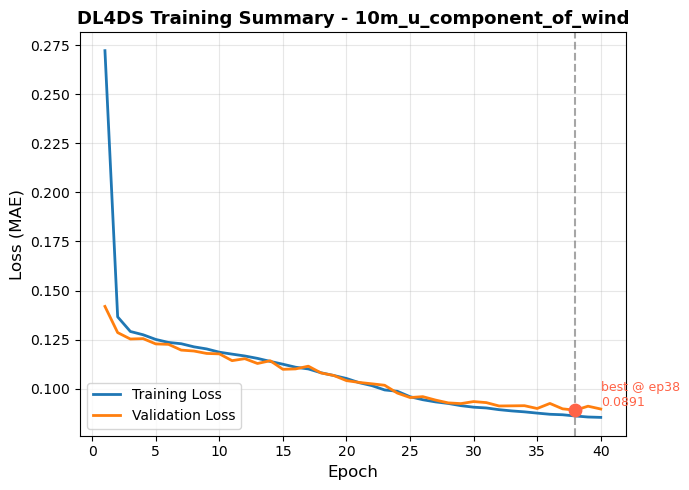


Final Training Loss: 0.085469
Final Validation Loss: 0.089733


In [12]:
# ── Save chart config ───────────────────────────────────────────────────
plot_var = var_names[0]
history = trainers[plot_var].fithist.history

_chart1_cfg = {
    'chart'         : 'training_curves',
    'variable'      : plot_var,
    'figsize'       : [7, 5],
    'best_epoch'    : int(np.argmin(history['val_loss']) + 1),
    'best_val_loss' : float(min(history['val_loss'])),
}
_json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_training_curves_config.json')

import matplotlib.pyplot as plt

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(history['loss']) + 1)

ax1.plot(epochs_range, history['loss'],     label='Training Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)

best_epoch = np.argmin(history['val_loss']) + 1
best_loss  = min(history['val_loss'])
ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color='tomato', zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9, color='tomato',
)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MAE)', fontsize=12)
ax1.set_title(f'DL4DS Training Summary - {plot_var}', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'dl4ds_training_curves.png', dpi=150)
plt.show()

print(f"\nFinal Training Loss: {history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")

[2026-04-02 02:14:01] Chart config saved -> chart_spatial_eval_config.json


/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


[2026-04-02 02:14:17] Chart saved → runs/20260402_004130/dl4ds_eval_2022-08-01.png


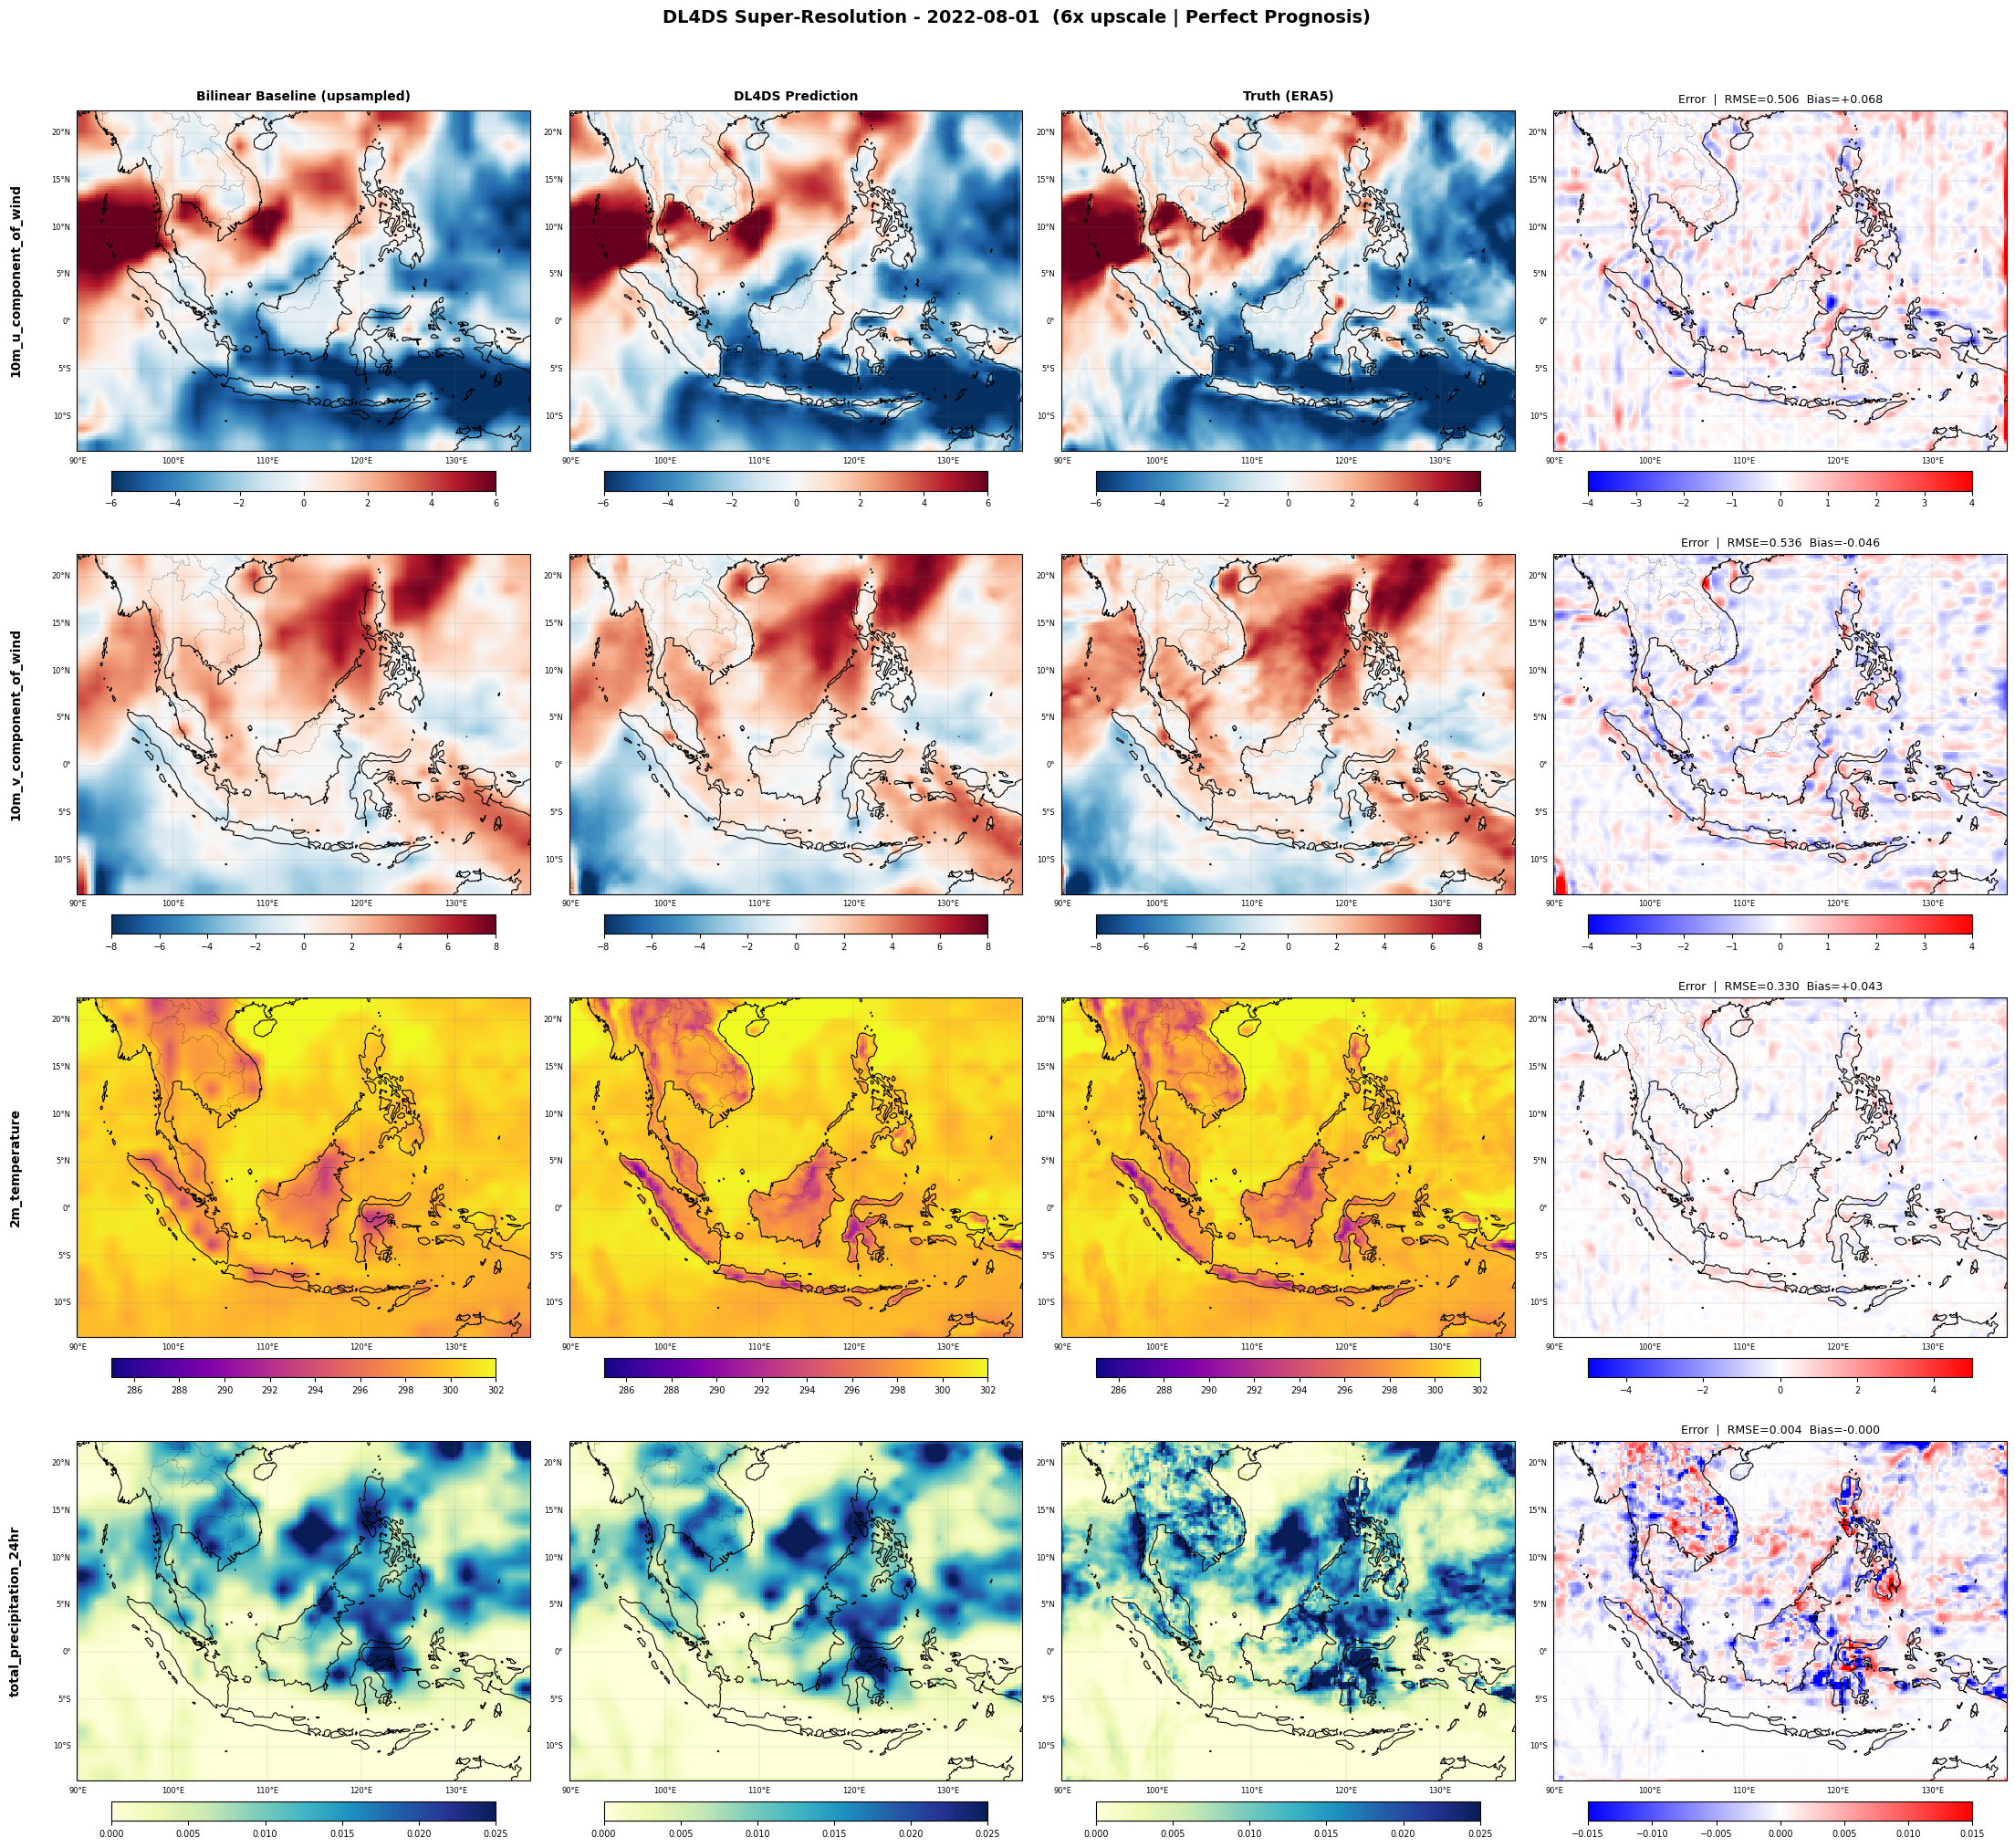

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps — same as regrid notebook
cmaps_field = ['RdBu_r', 'RdBu_r', 'plasma', 'YlGnBu']

if 'target_date' not in globals():
    target_date = np.datetime64('2022-08-01')

# ── Save chart config ───────────────────────────────────────────────────
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : 0,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : var_names,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_spatial_eval_config.json')

# ==============================
# Find index in test split
# ==============================
ref_var = var_names[0]
test_times = data[ref_var]['test_target_orig'].time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} -> {test_times[-1]}"
    )
idx = int(idx[0])

# ==============================
# Build per-variable predictions
# ==============================
predictions = {}
for var in var_names:
    model = trainers[var].model
    mean_val = norm_stats[var]['mean']
    std_val = norm_stats[var]['std']

    x_norm = data[var]['test_input'].isel(time=idx).values
    x_orig = data[var]['test_input_orig'].isel(time=idx).values[:, :, 0]
    y_true = data[var]['test_target_orig'].isel(time=idx).values[:, :, 0]

    y_pred_norm = model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
    y_pred = y_pred_norm[:, :, 0] * std_val + mean_val

    if y_pred.shape != y_true.shape:
        if y_pred.shape == y_true.shape[::-1]:
            y_true = y_true.T
        else:
            raise ValueError(f"Spatial mismatch for {var}: pred {y_pred.shape} vs true {y_true.shape}")

    x_up = tf.image.resize(
        np.expand_dims(data[var]['test_input_orig'].isel(time=idx).values, axis=0),
        [y_pred.shape[0], y_pred.shape[1]],
        method='bilinear',
    )[0].numpy()[:, :, 0]

    predictions[var] = {
        'raw': x_up,
        'pred': y_pred,
        'true': y_true,
    }

# ==============================
# Coordinate arrays
# ==============================
lons_lr = data[ref_var]['test_input_orig'].longitude.values
lats_lr = data[ref_var]['test_input_orig'].latitude.values
lons_hr = data[ref_var]['test_target_orig'].longitude.values
lats_hr = data[ref_var]['test_target_orig'].latitude.values

# ==============================
# Plot: N rows × 4 cols
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(var_names)

col_titles = [
    'Bilinear Baseline (upsampled)',
    'DL4DS Prediction',
    'Truth (ERA5)',
    'Error (Pred - Truth)',
]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={'projection': proj},
)
if n_vars == 1:
    axes = np.expand_dims(axes, axis=0)

for v, var_name in enumerate(var_names):
    raw_v  = predictions[var_name]['raw']
    pred_v = predictions[var_name]['pred']
    true_v = predictions[var_name]['true']
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v] if v < len(cmaps_field) else 'viridis'
    vmin = FIELD_VMIN[v] if v < len(FIELD_VMIN) else float(np.nanmin([raw_v.min(), pred_v.min(), true_v.min()]))
    vmax = FIELD_VMAX[v] if v < len(FIELD_VMAX) else float(np.nanmax([raw_v.max(), pred_v.max(), true_v.max()]))
    elim = ERROR_LIM[v]  if v < len(ERROR_LIM)  else float(np.nanpercentile(np.abs(err_v), 99))

    panels = [
        (lons_hr, lats_hr, raw_v,  cmap_f, vmin, vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin, vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin, vmax),
        (lons_hr, lats_hr, err_v, 'bwr', -elim, elim),
    ]

    for col, (lons, lats, field, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        if field.shape != (len(lats), len(lons)):
            field = field.T

        im = ax.pcolormesh(
            lons, lats, field,
            cmap=cmap, vmin=lo, vmax=hi,
            shading='nearest', transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
        ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor='lightcyan', zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 6}
        gl.ylabel_style = {'size': 6}

        cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight='bold', pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, var_name, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='center', rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}", fontsize=9, pad=6)

fig.suptitle(
    f"DL4DS Super-Resolution - {str(target_date)[:10]}  (6x upscale | Perfect Prognosis)",
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
save_fig(fig, f"dl4ds_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

In [15]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics, DL4DS version)
# ==============================
import csv as _csv
import numpy as np
import xarray as xr

# Keep label mapping consistent with notebook display names
_var_to_label = {
    '10m_u_component_of_wind': 'U10 (m/s)',
    '10m_v_component_of_wind': 'V10 (m/s)',
    '2m_temperature': 'T2m (K)',
    'total_precipitation_24hr': 'TP 24hr (mm)',
}

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in var_names:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

# Compute baseline RMSE on full HR grid (time-aligned only)
baseline_rmse_by_var = {}
for v_name in var_names:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print('\n' + '=' * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print('=' * 100)

BASELINE_EPS = 1e-8
_metrics_rows = []

for v_name in var_names:
    model = trainers[v_name].model
    mean_val = norm_stats[v_name]['mean']
    std_val = norm_stats[v_name]['std']

    n_test = len(data[v_name]['test_target'].time)
    pred_time = []
    true_time = []

    for j in range(n_test):
        x_norm = data[v_name]['test_input'].isel(time=j).values
        y_true = data[v_name]['test_target_orig'].isel(time=j).values[:, :, 0]

        y_pred_norm = model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
        y_pred = y_pred_norm[:, :, 0] * std_val + mean_val

        # Safety guard for swapped spatial axes
        if y_pred.shape != y_true.shape:
            if y_pred.shape == y_true.shape[::-1]:
                y_true = y_true.T
            else:
                raise ValueError(f"Spatial mismatch for {v_name}: pred {y_pred.shape} vs true {y_true.shape}")

        pred_time.append(y_pred)
        true_time.append(y_true)

    pred_v = np.stack(pred_time, axis=0)  # (T, H, W)
    true_v = np.stack(true_time, axis=0)  # (T, H, W)

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = _var_to_label.get(v_name, v_name)
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

    _metrics_rows.append({
        'variable': v_name,
        'label': label,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Corr': corr,
        'Baseline_RMSE': rmse_base,
        'Skill': float(skill),
    })

print('=' * 100)
print('\nSkill > 0 means DL4DS improves over bilinear interpolation baseline.')

metrics_df = pd.DataFrame(_metrics_rows).sort_values('Skill', ascending=False).reset_index(drop=True)

# Save both names for compatibility with previous cells and reference workflow
metrics_path_dl4ds = os.path.join(RUN_DIR, 'dl4ds_metrics.csv')
metrics_df.to_csv(metrics_path_dl4ds, index=False)
print(f"Saved: {metrics_path_dl4ds}")

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)

_log(f"Metrics saved -> {_csv_path}")

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f"=== Run finished  total_elapsed={str(_total).split('.')[0]} ===")
_log(f"All outputs in: {RUN_DIR}")
print(f"\nAll outputs saved to: {RUN_DIR}")


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   0.5143 |   0.3764 |  +0.0711 |   0.9633 |         0.6595 |  +0.2201
V10 (m/s)          |   0.5614 |   0.4163 |  -0.0756 |   0.9438 |         0.6327 |  +0.1127
T2m (K)            |   0.3433 |   0.2552 |  +0.0513 |   0.9530 |         0.5610 |  +0.3882
TP 24hr (mm)       |   0.0045 |   0.0022 |  -0.0004 |   0.9056 |         0.0046 |  +0.0272

Skill > 0 means DL4DS improves over bilinear interpolation baseline.
Saved: runs/20260402_004130/dl4ds_metrics.csv
[2026-04-02 02:18:19] Metrics saved -> runs/20260402_004130/metrics.csv
[2026-04-02 02:18:19] === Run finished  total_elapsed=1:36:48 ===
[2026-04-02 02:18:19] All outputs in: runs/20260402_004130

All outputs saved to: runs/20260402_004130
